# Credit Scoring with Fairness Improvement

This machine learning project's goal is to:
- Build a credit scoring model
- Observe bias between gender groups
- Apply mitigation technique
- Improve fairness and compare results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## Load the Dataset

We use German credit dataset where:
- Each row represents one person
- Columns contain personal and financial details
- The target is credit risk (good or bad)

In [2]:
df = pd.read_csv("german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


## Data Cleaning

We fill missing values with a simple placeholder.

In [4]:
df.fillna("Unknown", inplace=True)

## Convert Target Column

Machine learning models work with numbers.
We convert:
- good → 1
- bad → 0

In [5]:
df['Risk'] = df['Risk'].map({'good': 1, 'bad': 0})

## Convert Categorical Data

We convert text columns (like gender) into numbers
using one-hot encoding.

In [6]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Unnamed: 0,Age,Job,Credit amount,Duration,Risk,Sex_male,Housing_own,Housing_rent,Saving accounts_little,...,Checking account_little,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,0,67,2,1169,6,1,True,True,False,False,...,True,False,False,False,False,False,False,True,False,False
1,1,22,2,5951,48,0,False,True,False,True,...,False,True,False,False,False,False,False,True,False,False
2,2,49,1,2096,12,1,True,True,False,True,...,False,False,False,False,False,True,False,False,False,False
3,3,45,2,7882,42,1,True,False,False,True,...,True,False,False,False,False,False,True,False,False,False
4,4,53,2,4870,24,0,True,False,False,True,...,True,False,False,True,False,False,False,False,False,False


## Separate Features and Target

- X → input data
- y → output (credit risk)

In [7]:
X = df_encoded.drop('Risk', axis=1)
y = df_encoded['Risk']

## Train–Test Split

The model learns from training data
and is tested on unseen data.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train the Model

We use Logistic Regression because it is:
- Simple
- Easy to explain
- Suitable for binary classification

In [9]:
model = LogisticRegression(solver="liblinear", random_state=42)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


## Evaluate Accuracy

Accuracy tells us how often the model predicts correctly.

In [10]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.745

## Fairness Check (Before Mitigation)

We check whether approval rates differ
between male and female groups.


In [11]:
test_df = df_encoded.loc[y_test.index].copy()
test_df['prediction'] = y_pred

male_rate_before = test_df[test_df['Sex_male'] == 1]['prediction'].mean()
female_rate_before = test_df[test_df['Sex_male'] == 0]['prediction'].mean()

male_rate_before, female_rate_before


(np.float64(0.8611111111111112), np.float64(0.75))

## Bias Mitigation Technique

To reduce bias, we use a simple post-processing technique.
We adjust decision thresholds using prediction probabilities.


In [12]:
y_prob = model.predict_proba(X_test)[:, 1]
test_df['probability'] = y_prob
test_df['prediction_default'] = (test_df['probability'] >= 0.5).astype(int)

# Apply Mitigation

test_df['prediction_mitigated'] = test_df['prediction_default']

test_df.loc[
    (test_df['Sex_male'] == 0) & (test_df['probability'] >= 0.45),
    'prediction_mitigated'
] = 1


## Fairness Check (After Mitigation)

In [13]:
male_rate_after = test_df[test_df['Sex_male'] == 1]['prediction_mitigated'].mean()
female_rate_after = test_df[test_df['Sex_male'] == 0]['prediction_mitigated'].mean()

male_rate_after, female_rate_after

(np.float64(0.8611111111111112), np.float64(0.7857142857142857))

## Fairness Comparison Plots


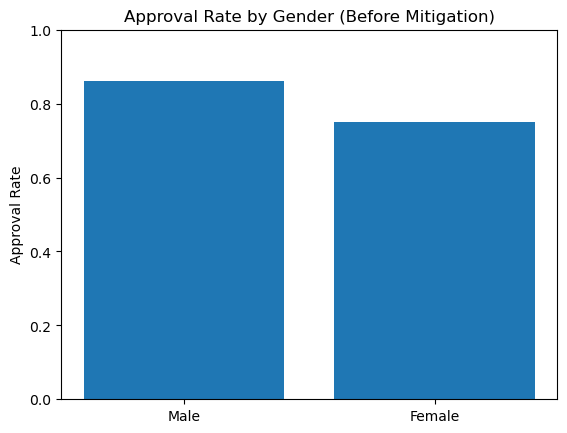

In [14]:
plt.figure()
plt.bar(['Male', 'Female'], [male_rate_before, female_rate_before])
plt.title("Approval Rate by Gender (Before Mitigation)")
plt.ylabel("Approval Rate")
plt.ylim(0, 1)
plt.show()


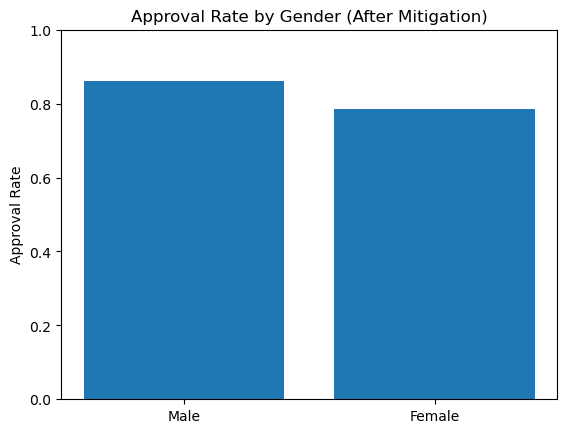

In [15]:
plt.figure()
plt.bar(['Male', 'Female'], [male_rate_after, female_rate_after])
plt.title("Approval Rate by Gender (After Mitigation)")
plt.ylabel("Approval Rate")
plt.ylim(0, 1)
plt.show()


## Conclusion

This project demonstrates how bias can exist
in machine learning models used for credit scoring.

By applying a simple threshold-based mitigation technique,
we were able to reduce the difference in approval rates
between male and female groups.

This shows that fairness can be improved even with
simple models and simple techniques.


In [16]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

print("Model Saved!")

Model Saved!
